In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [159]:
# Change time period to years

N_SIM = 100
n_periods = 18
mu_ibap_price,sigma_ibap_price = 1.6467,0.035
mu_HF_price,sigma_HF_price = 0.0198, 0.0876
mu_HF_throughput,sigma_HF_throughput = 294480, 121.34   
mu_ibap_throughput,sigma_ibap_throughput = 6637824,576
mu_raw_mat,sigma_raw_mat = 3136440,313644
annual_inflation = 0.02
mu_inflation = annual_inflation
sigma_inflation = 0.002



# Simulation helpers
# Build one stochastic driver at a time while holding all other inputs fixed.
def simulate_gbm_paths(initial_log_price, sigma, n_sim, n_periods, drift=0.0, dt=1.0):
    initial_price = np.exp(initial_log_price)

    if n_periods == 1:
        return np.full((n_sim, 1), initial_price, dtype=float)

    shocks = np.random.normal(0, 1, size=(n_sim, n_periods - 1))
    log_returns = (drift - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks
    cumulative_log_returns = np.cumsum(log_returns, axis=1)
    log_price_paths = np.column_stack([
        np.full(n_sim, np.log(initial_price)),
        np.log(initial_price) + cumulative_log_returns
    ])

    return np.exp(log_price_paths)

def constant_path(value, n_sim=N_SIM, n_periods=n_periods):
    return np.full((n_sim, n_periods), value, dtype=float)

baseline_values = {
    'price_of_ibap': np.exp(mu_ibap_price),
    'price_of_HF': np.exp(mu_HF_price),
    'HF_throughput': mu_HF_throughput,
    'ibap_throughput': mu_ibap_throughput,
    'raw_material_cost': mu_raw_mat,
    'inflation': mu_inflation,
}

def build_single_factor_inputs(stochastic_driver, overrides=None):
    overrides = overrides or {}
    inputs = {
        name: constant_path(value)
        for name, value in baseline_values.items()
    }

    if stochastic_driver == 'price_of_ibap':
        inputs['price_of_ibap'] = simulate_gbm_paths(
            overrides.get('mu_ibap_price', mu_ibap_price),
            overrides.get('sigma_ibap_price', sigma_ibap_price),
            N_SIM,
            n_periods,
            drift=overrides.get('drift_ibap_price', 0.0),
        )
    elif stochastic_driver == 'price_of_HF':
        inputs['price_of_HF'] = simulate_gbm_paths(
            overrides.get('mu_HF_price', mu_HF_price),
            overrides.get('sigma_HF_price', sigma_HF_price),
            N_SIM,
            n_periods,
            drift=overrides.get('drift_HF_price', 0.0),
        )
    elif stochastic_driver == 'HF_throughput':
        inputs['HF_throughput'] = np.random.normal(
            loc=overrides.get('mu_HF_throughput', mu_HF_throughput),
            scale=overrides.get('sigma_HF_throughput', sigma_HF_throughput),
            size=(N_SIM, n_periods),
        )
    elif stochastic_driver == 'ibap_throughput':
        inputs['ibap_throughput'] = np.random.normal(
            loc=overrides.get('mu_ibap_throughput', mu_ibap_throughput),
            scale=overrides.get('sigma_ibap_throughput', sigma_ibap_throughput),
            size=(N_SIM, n_periods),
        )
    elif stochastic_driver == 'raw_material_cost':
        inputs['raw_material_cost'] = np.random.normal(
            loc=overrides.get('mu_raw_mat', mu_raw_mat),
            scale=overrides.get('sigma_raw_mat', sigma_raw_mat),
            size=(N_SIM, n_periods),
        )
    elif stochastic_driver == 'inflation':
        inputs['inflation'] = np.random.normal(
            loc=overrides.get('mu_inflation', mu_inflation),
            scale=overrides.get('sigma_inflation', sigma_inflation),
            size=(N_SIM, n_periods),
        )
    else:
        raise ValueError(f'Unknown stochastic driver: {stochastic_driver}')

    return inputs

sample_inputs = build_single_factor_inputs('price_of_ibap')
price_of_ibap = sample_inputs['price_of_ibap']
price_of_HF = sample_inputs['price_of_HF']


In [160]:
print(price_of_ibap[:1,:20])
print(price_of_HF[:1,:20])


[[5.18982511 5.17718658 5.15793291 5.45865183 5.26151001 5.58651177
  5.66955086 5.69862914 5.40195329 5.30484137 5.31991199 5.34329564
  5.64916902 5.32424369 5.15736328 5.24358814 5.24169766 5.1093163 ]]
[[1.01999732 1.01999732 1.01999732 1.01999732 1.01999732 1.01999732
  1.01999732 1.01999732 1.01999732 1.01999732 1.01999732 1.01999732
  1.01999732 1.01999732 1.01999732 1.01999732 1.01999732 1.01999732]]


In [161]:
# def npv_vectorized(price_of_ibap, ibap_throughput, 
#                    price_of_HF,HF_throughput,
#                    raw_material_cost, inflation, discount_rate,
#                    return_details=False):
#     price_of_ibap = np.asarray(price_of_ibap)
#     ibap_throughput = np.asarray(ibap_throughput)
#     price_of_HF = np.asarray(price_of_HF)
#     HF_throughput = np.asarray(HF_throughput)
#     raw_material_cost = np.broadcast_to(np.asarray(raw_material_cost), ibap_throughput.shape)
#     inflation = np.broadcast_to(np.asarray(inflation), ibap_throughput.shape)
#     price_of_ibap = np.broadcast_to(price_of_ibap, ibap_throughput.shape)
#     price_of_HF = np.broadcast_to(price_of_HF, ibap_throughput.shape)

#     periods = ibap_throughput.shape[1]
#     t = np.arange(1, periods + 1)
#     t_matrix = np.broadcast_to(t, ibap_throughput.shape)

#     revenue = price_of_ibap * ibap_throughput + price_of_HF * HF_throughput
#     # cost = raw_material_cost * (1 + inflation) ** t + 408240 
#     cost = np.full_like(revenue, 38658904, dtype=float)
#     net_cash_flow = revenue - cost
#     discounted_cash_flow = net_cash_flow / (1 + discount_rate) ** t

#     if not return_details:
#         return discounted_cash_flow

#     sim_idx, period_idx = np.indices(revenue.shape)
#     details = pd.DataFrame({
#         'simulation': sim_idx.ravel(),
#         'period': period_idx.ravel() + 1,
#         'price_of_ibap': price_of_ibap.ravel(),
#         'ibap_throughput': ibap_throughput.ravel(),
#         'price_of_HF': price_of_HF.ravel(),
#         'HF_throughput': HF_throughput.ravel(),
#         'raw_material_cost': raw_material_cost.ravel(),
#         'inflation': inflation.ravel(),
#         'discount_rate': np.broadcast_to(discount_rate, revenue.shape).ravel(),
#         'time_index': t_matrix.ravel(),
#         'revenue': revenue.ravel(),
#         'cost': cost.ravel(),
#         'net_cash_flow': net_cash_flow.ravel(),
#         'discounted_cash_flow': discounted_cash_flow.ravel(),
#     })

#     return discounted_cash_flow, details


In [162]:
def npv_vectorized(price_of_ibap=5.19, ibap_throughput=6637824, 
                   price_of_HF=np.exp(0.0198), HF_throughput=294480,
                   raw_material_cost=3136440, inflation=mu_inflation, discount_rate=0.15,
                   return_details=False):
    shape = None
    for value in [price_of_ibap, ibap_throughput, price_of_HF, HF_throughput, raw_material_cost, inflation]:
        arr = np.asarray(value)
        if arr.ndim == 2:
            shape = arr.shape
            break

    if shape is None:
        shape = (1, 1)

    price_of_ibap = np.broadcast_to(np.asarray(price_of_ibap, dtype=float), shape)
    ibap_throughput = np.broadcast_to(np.asarray(ibap_throughput, dtype=float), shape)
    price_of_HF = np.broadcast_to(np.asarray(price_of_HF, dtype=float), shape)
    HF_throughput = np.broadcast_to(np.asarray(HF_throughput, dtype=float), shape)
    raw_material_cost = np.broadcast_to(np.asarray(raw_material_cost, dtype=float), shape)
    inflation = np.broadcast_to(np.asarray(inflation, dtype=float), shape)

    periods = shape[1]
    t = np.arange(1, periods + 1)
    t_matrix = np.broadcast_to(t, shape)

    revenue = price_of_ibap * ibap_throughput + price_of_HF * HF_throughput
    cost = raw_material_cost * (1 + inflation) ** t
    net_cash_flow = revenue - cost
    discounted_cash_flow = net_cash_flow / (1 + discount_rate) ** t

    if not return_details:
        return discounted_cash_flow

    sim_idx, period_idx = np.indices(shape)
    details = pd.DataFrame({
        'simulation': sim_idx.ravel(),
        'period': period_idx.ravel() + 1,
        'price_of_ibap': price_of_ibap.ravel(),
        'ibap_throughput': ibap_throughput.ravel(),
        'price_of_HF': price_of_HF.ravel(),
        'HF_throughput': HF_throughput.ravel(),
        'raw_material_cost': raw_material_cost.ravel(),
        'inflation': inflation.ravel(),
        'time_index': t_matrix.ravel(),
        'revenue': revenue.ravel(),
        'cost': cost.ravel(),
        'net_cash_flow': net_cash_flow.ravel(),
        'discounted_cash_flow': discounted_cash_flow.ravel(),
    })

    return discounted_cash_flow, details

# simulating ONLY iBAP Price as Stochastic

In [163]:
# npv_results = npv_vectorized(
#     price_of_ibap,
#     ibap_throughput,
#     price_of_HF,HF_throughput,
#     raw_material_cost,
#     inflation,
#     # Baseline in lecture notes
#     discount_rate=0.15,
#     return_details=True
# )

# simulation_details.head()

scenario_inputs = build_single_factor_inputs('price_of_ibap')

npv_results = npv_vectorized(
    price_of_ibap=scenario_inputs['price_of_ibap'],
    ibap_throughput=scenario_inputs['ibap_throughput'],
    price_of_HF=scenario_inputs['price_of_HF'],
    HF_throughput=scenario_inputs['HF_throughput'],
    raw_material_cost=scenario_inputs['raw_material_cost'],
    inflation=scenario_inputs['inflation'],
    discount_rate=0.15,
)


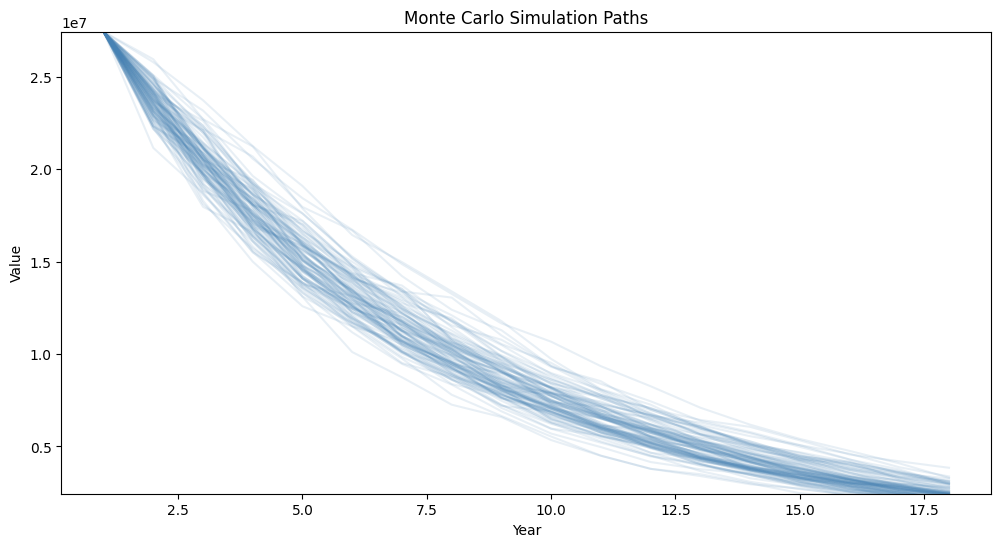

In [164]:
plt.figure(figsize=(12, 6))

for i in range(npv_results.shape[0]):
    plt.plot(range(1, npv_results.shape[1] + 1), npv_results[i], alpha=0.12, color="steelblue")

# Set y-limits using percentiles to ignore extreme outliers
ymin = np.percentile(npv_results, 5)
ymax = np.percentile(npv_results, 95)
plt.ylim(ymin, ymax)

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Monte Carlo Simulation Paths")
plt.show()

# Only HF price is stochastic with changed volatility

- Exploring different characteristics of the stochastic drivers


Before:
HF_Price - log normal ~ (0.0198,0.0876)

After
HF_Price - lognormal ~ (0.0198,0.1095)




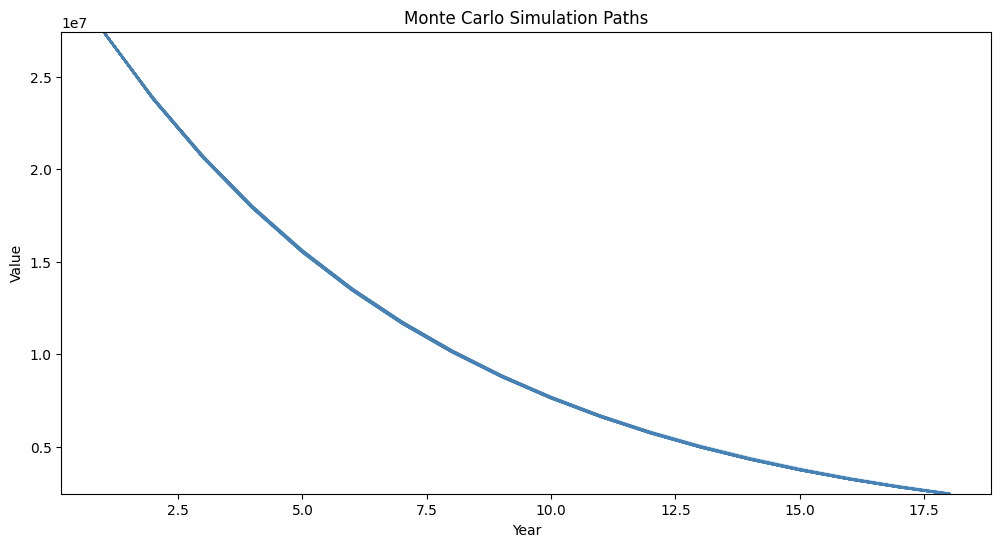

In [165]:
scenario_inputs = build_single_factor_inputs(
    'price_of_HF',
    overrides={'sigma_HF_price': 0.1095}
)

npv_results = npv_vectorized(
    price_of_ibap=scenario_inputs['price_of_ibap'],
    ibap_throughput=scenario_inputs['ibap_throughput'],
    price_of_HF=scenario_inputs['price_of_HF'],
    HF_throughput=scenario_inputs['HF_throughput'],
    raw_material_cost=scenario_inputs['raw_material_cost'],
    inflation=scenario_inputs['inflation'],
    discount_rate=0.15 # Baseline in lecture notes
)




plt.figure(figsize=(12, 6))

for i in range(npv_results.shape[0]):
    plt.plot(range(1, npv_results.shape[1] + 1), npv_results[i], alpha=0.3, color="steelblue")

# Set y-limits using percentiles to ignore extreme outliers
ymin = np.percentile(npv_results, 5)
ymax = np.percentile(npv_results, 95)
plt.ylim(ymin, ymax)

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Monte Carlo Simulation Paths")
plt.show()

In [166]:
# Checks 
scenario_inputs['price_of_HF'][:2,:20]

array([[1.01999732, 0.98615005, 0.78361126, 0.92569151, 1.05113188,
        1.27201114, 1.13654504, 1.05902254, 0.96993022, 1.10784705,
        1.03464425, 1.20424342, 1.27663332, 1.41704273, 1.18501448,
        1.40490085, 1.30983282, 1.32512258],
       [1.01999732, 0.96311668, 0.99762151, 1.12925079, 0.84688116,
        0.79882413, 0.78876953, 0.80765245, 0.75896641, 0.79215805,
        0.7612285 , 0.7521509 , 0.88473861, 0.90033321, 0.96845075,
        1.01891027, 1.08353169, 1.07134262]])

# Only Inflation is stochastic

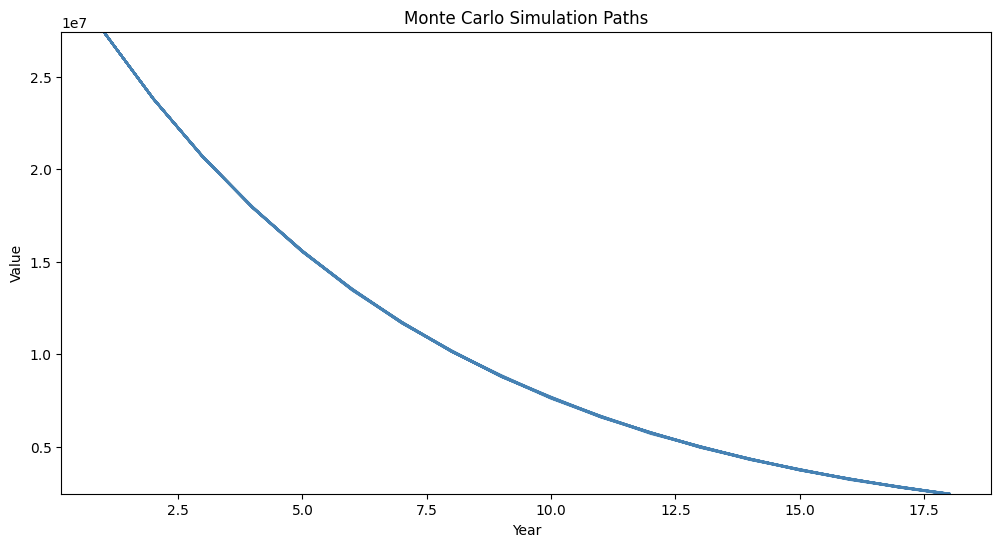

In [167]:
scenario_inputs = build_single_factor_inputs('inflation')

npv_results, inflation_debug = npv_vectorized(
    price_of_ibap=scenario_inputs['price_of_ibap'],
    ibap_throughput=scenario_inputs['ibap_throughput'],
    price_of_HF=scenario_inputs['price_of_HF'],
    HF_throughput=scenario_inputs['HF_throughput'],
    raw_material_cost=scenario_inputs['raw_material_cost'],
    inflation=scenario_inputs['inflation'],
    discount_rate=0.15, # Baseline in lecture notes
    return_details=True,
)

inflation_debug[['inflation', 'cost', 'revenue', 'discounted_cash_flow']].agg(['min', 'max'])




plt.figure(figsize=(12, 6))

for i in range(npv_results.shape[0]):
    plt.plot(range(1, npv_results.shape[1] + 1), npv_results[i], alpha=0.3, color="steelblue")

# Set y-limits using percentiles to ignore extreme outliers
ymin = np.percentile(npv_results, 5)
ymax = np.percentile(npv_results, 95)
plt.ylim(ymin, ymax)

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Monte Carlo Simulation Paths")
plt.show()